<a href="https://colab.research.google.com/github/ryueuitae/core-study/blob/main/chapter_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 8. Dimensionally Reduction

# 차원 축소가 필요한 이유?
1. 차원이 높아지면 공간이 기하급수적으로 커져서 데이터가 희박해짐<br>
ex. 각 축을 10칸으로 나눈다고 했을 때


*   1차원: 10칸
*   2차원: 10x10=100칸
* 3차원: 1000칸
* 10차원: 100억 칸
-> 샘플이 1000개 있어도 10차원에서는 대부분의 칸이 비어있음

2. 데이터가 희박하므로 모델은 서로 멀리 떨어진 샘플들로 추측해야 함. 그래서 예측이 틀리기 쉽고, 훈련 데이터가 조금만 달라져도 예측이 흔들림

3. 데이터 사이에 빈 공간이 많기에 샘플들 사이의 경계를 어떻게 그려도 훈련오차가 늘지 않음. 이는 훈련 데이터에는 맞지만 새 샘플이 들어오면 엉뚱하게 예측함. <과적합>




In [8]:
# 기본 설정
import sys

assert sys.version_info >= (3, 7)

import matplotlib.pyplot as plt

plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

import sys
if 'google.colab' in sys.modules:
    !sudo apt-get -qq -y install fonts-nanum
    import matplotlib.font_manager as fm
    font_files = fm.findSystemFonts(fontpaths=['/usr/share/fonts/truetype/nanum'])
    for fpath in font_files:
        fm.fontManager.addfont(fpath)

import matplotlib

matplotlib.rc('font', family='NanumBarunGothic')
matplotlib.rcParams['axes.unicode_minus'] = False

from pathlib import Path

IMAGES_PATH = Path() / "images" / "dim_reduction"
IMAGES_PATH.mkdir(parents=True, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = IMAGES_PATH / f"{fig_id}.{fig_extension}"
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

# 차원 축소를 위한 접근 방법
투영(Projection)
* 고차원의 데이터라도 실제로는 훨씬 낮은 차원의 부분 공간 근처에 몰려있는 경우가 많음.
* 3D 공간상의 점들이 비스듬한 평면을 이루고 있을 때, 각 점들을 평면에 수직으로 떨어뜨리면 2D 데이터가 됨
* 한계: 공간상에서 말려있는 층에서는, 평면이라면 멀리 떨어져있을 점들이 투영했을 때 겹쳐지는 문제 발생

매니폴드 학습(Manifold Learning)
* 매니폴드란? 고차원 공간 안에 휘어지거나 고인 채로 놓인 저차원 모양
* d차원 매니폴드 = 국소적으로 보면 d차원 평면처럼 보이는 모양
* 원래 3D에선 단순한 평면이었는데 펼치고 나면 복잡하게 꼬이는 경우도 있음, 매니폴드를 펼친다고 문제가 항상 쉬워지지는 않음

# 주성분 분석(PCA)
1. 분산 보존
* 분산이 크면 정보량이 많다: 분산이 크면 그 방향에서 샘플들끼리 차이가 커서 샘플 구분이 명확하기 때문
* 분산은 정보량이기 때문에 보존해야 함, 분산이 가장 큰 방향을 골라야 함
* 분산이 가장 큰 방향 = 원래 점과 투영된 점 사이 거리(제곱)의 평균이 가장 작은 직선

2. 주성분<br>
 분산이 가장 큰 축을 찾음(PC1)
-> PC1과 직교하면서 남은 분산이 가장 큰 축(PC2) -> 원래 차원수만큼 반복

*   SVD: 데이터 행렬을 넣으면 분산이 최대인 방향들을 순서대로 뽑아서 주성분을 계산해줌



In [15]:
import numpy as np
from scipy.spatial.transform import Rotation

m = 60                                   # 점 60개
X = np.zeros((m, 3))                     # 3차원 데이터 틀 만들기
np.random.seed(42)                       # 결과 고정
angles = (np.random.rand(m) ** 3 + 0.5) * 2 * np.pi   # 점들을 고르지 않게 배치
X[:, 0], X[:, 1] = np.cos(angles), np.sin(angles) * 0.5  # 납작한 타원 모양
X += 0.28 * np.random.randn(m, 3)        # 잡음 추가
X = Rotation.from_rotvec([np.pi / 29, -np.pi / 20, np.pi / 4]).apply(X)  # 비스듬하게 회전
X += [0.2, 0, 0.2]                       # 약간 이동

In [16]:
X_centered = X - X.mean(axis=0)
U, s, Vt = np.linalg.svd(X_centered)
c1 = Vt[0]
c2 = Vt[1]

SVD 분해? 데이터 행렬을 "새 축 방향", "그 축으로 퍼진 정도", "각 점의 새 좌표" 세 부분으로 분해하는 과정

X = U × Σ × Vᵀ

3. d차원으로 투영하기


*   주성분 구한 후 상위 d개 골라서 그 축들로 데이터 투영



In [17]:
W2 = Vt[:2].T
X2D = X_centered @ W2
print(X2D.shape)   # (60, 2) → 점 60개가 2차원이 됨

(60, 2)


4. 사이킷런 이용하기<br>
사이킷런을 이용하여 위 과정 단순화: 중앙정렬, SVD, 투영을 모두 알아서 수행

In [19]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X2D = pca.fit_transform(X)

5. 설명된 분산의 비율<br>
: 각 주성분이 전체 분산 중 몇%를 담당하는지

In [20]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca.fit(X)

print(pca.explained_variance_ratio_)

[0.7578477  0.15186921]


* 3D 데이터에 PCA를 적용했을 때, PC1은 약 76%, PC2는 약 15%가 나옴
* 두 개를 더하면 91%, 즉 3D에서 2D로 줄였을 때 퍼짐의 91%가 남고 9%가 버려짐

6. 적절한 차원 수 선택<br>
방법 1) 분산 95%를 유지하는 차원수 고르기<br>
: 가장 많이 사용되는 기준. 주성분 비율 합이 처음으로 95%를 넘는 지점에서 멈춘다
| 주성분 | 비율 | 누적 합 |
|---|---|---|
| PC1 | 0.50 | 0.50 |
| PC2 | 0.30 | 0.80 |
| PC3 | 0.16 | 0.96 ← 95% 처음 넘음 |
| PC4 | 0.04 | 1.00 |

In [21]:
from sklearn.datasets import fetch_openml
from sklearn.decomposition import PCA
import numpy as np

mnist = fetch_openml('mnist_784', as_frame=False)
X_train = mnist.data[:60000]            # 앞 6만 장을 훈련용으로

pca = PCA()                             # 차원 수 지정 안 함 → 주성분 전부 계산
pca.fit(X_train)
cumsum = np.cumsum(pca.explained_variance_ratio_)   # 누적 합
d = np.argmax(cumsum >= 0.95) + 1       # 95% 처음 넘는 위치
print(d)                                # 154

154




*   784차원 중 분산을 95% 유지하려면 154차원까지 남기면 됨


방법 1-2) 사이킷런을 이용하여 과정 단순화

In [ ]:
pca = PCA(n_components=0.95)            # "분산 95% 유지"
X_reduced = pca.fit_transform(X_train)
print(pca.n_components_)                # 154

방법 2) 그래프로 보고 정하기(엘보)<br>
: 분산 비율 누적합을 그래프로 볼 때 빠르게 올라가다 평평해지는 지점까지 남긴다.

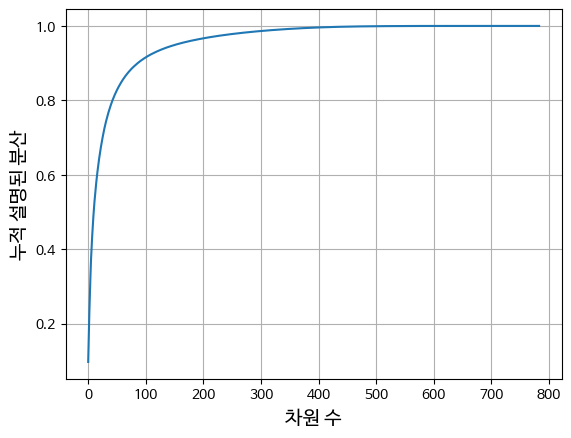

In [22]:
import matplotlib.pyplot as plt

plt.plot(cumsum)
plt.xlabel("차원 수")
plt.ylabel("누적 설명된 분산")
plt.grid(True)
plt.show()

방법 3) 성능 기준으로 정하기<br>
: 차원 축소를 분류 등의 다른 작업의 전처리로 쓰는 경우에는, 분산 비율보다 최종 모델 성능을 기준으로 차원수를 고르는 것이 합리적.<br>
-> 차원수를 하이퍼파라미터로 보고, PCA와 분류 모델을 파이프라인으로 묶은 다음 여러 값을 시도해서 가장 성능 좋은 것을 찾음

In [23]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.pipeline import make_pipeline

y_train = mnist.target[:60000]      # 정답 레이블

clf = make_pipeline(PCA(random_state=42),
                    RandomForestClassifier(random_state=42))
param_distrib = {
    "pca__n_components": np.arange(10, 80),
    "randomforestclassifier__n_estimators": np.arange(50, 500)
}
rnd_search = RandomizedSearchCV(clf, param_distrib, n_iter=10, cv=3,
                                random_state=42)
rnd_search.fit(X_train[:1000], y_train[:1000])
print(rnd_search.best_params_)

{'randomforestclassifier__n_estimators': np.int64(475), 'pca__n_components': np.int64(57)}




*   최적 차원 수는 57: 95% 기준인 154보다 훨씬 적지만 이 분류 작업에서는 성능 최상
-> 분산을 많이 남기는 것보다 분류에 필요한 정보만 남기는 것이 나을 수도 있음



7. 압축을 위한 PCA<br>
차원을 축소하면 데이터 크기도 줄어들기 때문에 PCA를 데이터 압축에도 활용 가능하며, 압축된 데이터를 복원하는 것도 가능함.
* 압축: 784 -> 154<br>
이미지를 표현하는 정보량이 784에서 154로 줄었으므로 데이터 크기도 원래의 20%로 줄지만 분산은 95%가 남아있음<br>
-> 줄인 데이터로 분류 모델을 학습하면 학습 속도 크게 향상
* 복원: 154 -> 784<br>
줄인 데이터를 다시 원래대로 복원 가능하나, 버린 정보는 되살릴 수 없으므로 복원된 이미지는 원본보다 약간 흐릿함<br>
-> 원본과 복원본의 차이(거리 제곱 평균): 재구성 오차

In [24]:
pca = PCA(n_components=154)
X_reduced = pca.fit_transform(X_train)          # 압축: 784 → 154
X_recovered = pca.inverse_transform(X_reduced)  # 복원: 154 → 784

print(X_train.shape, X_reduced.shape, X_recovered.shape)

(60000, 784) (60000, 154) (60000, 784)


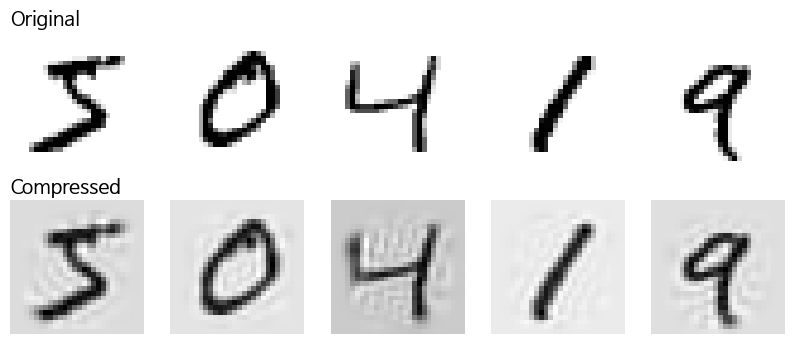

In [25]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i in range(5):
    axes[0, i].imshow(X_train[i].reshape(28, 28), cmap="binary")
    axes[0, i].axis("off")
    axes[1, i].imshow(X_recovered[i].reshape(28, 28), cmap="binary")
    axes[1, i].axis("off")
axes[0, 0].set_title("Original", loc="left")
axes[1, 0].set_title("Compressed", loc="left")
plt.show()

In [26]:
# 재구성 오차 계산
error = np.mean((X_train - X_recovered) ** 2)
print(error)

217.79366111265466


8. 랜덤 PCA<br>
주성분을 정확하게 다 구하는 대신, 필요한 개수만 빠르게 근사해서 구하는 방법


*   일반 PCA: 주성분 전부 계산, 계산해놓고 버리는 성분이 많아 속도가 느림
*   랜덤 PCA: 확률적인 방법으로 앞쪽 d개 주성분만 근사해서 구함, 특히 줄일 차원 수 d가 원래 n보다 훨씬 작을 때 속도 크게 향상



In [27]:
rnd_pca = PCA(n_components=154, svd_solver="randomized", random_state=42)
X_reduced = rnd_pca.fit_transform(X_train)

In [28]:
%time PCA(n_components=154, svd_solver="full").fit(X_train)
%time PCA(n_components=154, svd_solver="randomized", random_state=42).fit(X_train)

CPU times: user 25.3 s, sys: 482 ms, total: 25.8 s
Wall time: 15.4 s
CPU times: user 18.6 s, sys: 515 ms, total: 19.1 s
Wall time: 11.6 s


PCA(n_components=154, random_state=42, svd_solver='randomized')

9. 점진적 PCA<br>
데이터를 한번에 다 넣지 않고 조금씩 나눠 넣으면서 PCA를 학습하는 방법


*   일반 PCA: SVD를 계산하려면 훈련 데이터 전체를 메모리에 한 번에 올려야함<br>
-> 데이터가 매우 크면 컴퓨터 메모리에 다 들어가지 않아 실행 자체가 안됨
*   점진적 PCA: 데이터를 작은 묶음(미니배치)으로 나눠서 하나씩 학습<br>
-> 한번에 하나의 배치만 있으면 되므로 큰 데이터도 처리 가능<br>
-> 새 데이터가 계속 들어오는 온라인 학습에서도 활용 가능


In [29]:
from sklearn.decomposition import IncrementalPCA

n_batches = 100
inc_pca = IncrementalPCA(n_components=154)
for X_batch in np.array_split(X_train, n_batches):
    inc_pca.partial_fit(X_batch)

X_reduced = inc_pca.transform(X_train)

In [30]:
filename = "my_mnist.mmap"

# 1) 데이터를 디스크 파일로 저장
X_mmap = np.memmap(filename, dtype="float32", mode="write", shape=X_train.shape)
X_mmap[:] = X_train
X_mmap.flush()

# 2) 파일을 memmap으로 다시 불러오기
X_mmap = np.memmap(filename, dtype="float32", mode="readonly").reshape(-1, 784)

# 3) 점진적 PCA 학습
batch_size = X_mmap.shape[0] // n_batches
inc_pca = IncrementalPCA(n_components=154, batch_size=batch_size)
inc_pca.fit(X_mmap)

IncrementalPCA(batch_size=600, n_components=154)

# 랜덤 투영
주성분을 찾지 않고 무작위로 고른 방향들로 투영하는 방법


*   존슨-린덴스트라우스 보조정리
>점이 m개 있을 때, 적당한 차원 d로 무작위 투영하면 모든 점 쌍 사이의 거리가 원래 거리에서 크게 벗어나지 않는다.



In [31]:
# 필요한 최소 차원을 계산해주는 함수
from sklearn.random_projection import johnson_lindenstrauss_min_dim

m, eps = 5000, 0.1
d = johnson_lindenstrauss_min_dim(m, eps=eps)
print(d)   # 7300

7300




*   위 계산은 원래 차원 n 없이 필요한 샘플 수와 허용 오차만 사용됨<br>
-> 원래 차원이 매우 높을 때 효과가 큼<br>
ex. 원래 차원이 2만이어도, 100만이어도 7300차원으로 줄일 수 있음


In [32]:
# 무작위 행렬 곱하기: 데이터를 안 보고 무작위로 방향 결정
import numpy as np

n = 20000                                    # 원래 차원 2만
np.random.seed(42)
P = np.random.randn(d, n) / np.sqrt(d)       # 무작위 투영 행렬 (7300 × 20000)
X = np.random.randn(m, n)                    # 연습용 가짜 데이터 (5000 × 20000)
X_reduced = X @ P.T                          # 투영: (5000 × 7300)

In [33]:
# 사이킷런으로 하기: 필요한 차원 계산, 무작위 행렬 생성, 투영 자동 수행
from sklearn.random_projection import GaussianRandomProjection

gaussian_rnd_proj = GaussianRandomProjection(eps=eps, random_state=42)
X_reduced = gaussian_rnd_proj.fit_transform(X)

In [34]:
# 더 효율적인 방식: 무작위 행렬을 대부분의 성분이 0인 희소행렬로 만듧
from sklearn.random_projection import SparseRandomProjection

sparse_rnd_proj = SparseRandomProjection(eps=eps, random_state=42)
X_reduced = sparse_rnd_proj.fit_transform(X)

In [35]:
# 차원이 줄었는지 확인
print(X.shape)          # (5000, 20000)
print(X_reduced.shape)  # (5000, 7300)

# 거리가 유지되었는지 확인
from sklearn.metrics import pairwise_distances

idx = np.random.choice(m, 100, replace=False)       # 점 100개 무작위로 선택
d_orig = pairwise_distances(X[idx])                 # 투영 전 거리
d_red = pairwise_distances(X_reduced[idx])          # 투영 후 거리

mask = ~np.eye(100, dtype=bool)                     # 자기 자신과의 거리(0)는 제외
ratio = d_red[mask] / d_orig[mask]                  # 투영 후 거리 ÷ 투영 전 거리

print("최소:", ratio.min())
print("최대:", ratio.max())
print("평균:", ratio.mean())

(5000, 20000)
(5000, 7300)
최소: 0.9695160541359982
최대: 1.0297882682779098
평균: 1.0003760385008005


# 지역 선형 임베딩(LLE)
투영 계열인 PCA와 달리 매니폴드 학습 계열로, 휘어진 데이터를 펼칠 수 있음<br>
핵심 아이디어: 이웃한 점들과의 관계를 기억했다가 그대로 다시 그리기<br>
-운동장에 사람들이 구불구불하게 서있을 때, 본인 바로 옆 이웃 몇 명과의 관계만 기억해두고 다시 펴진 채로 줄을 세우면 줄이 구불구불하지 않고 펴지지만 각자 옆에 누가 있는지는 그대로 유지<br>
<br>
1단계) 각 점을 이웃들로 표현하는 가중치 찾기<br>
-> 각 점마다 가장 가까운 이웃 k개를 찾은 후, 그 점을 이웃들의 가중평균으로 최대한 비슷하게 표현하는 가중치 구하기<br>
ex. 이웃 점 B와 점 C 사이에 위치한 점 A<br>= 0.7xB+0.3xC<br>
2단계) 그 관계를 유지하는 저차원 좌표 찾기<br>
저차원에 구해놓은 가중치 그대로 성립하도록 점 새로 배치

In [36]:
from sklearn.datasets import make_swiss_roll
from sklearn.manifold import LocallyLinearEmbedding

X_swiss, t = make_swiss_roll(n_samples=1000, noise=0.2, random_state=42)
lle = LocallyLinearEmbedding(n_components=2, n_neighbors=10, random_state=42)
X_unrolled = lle.fit_transform(X_swiss)

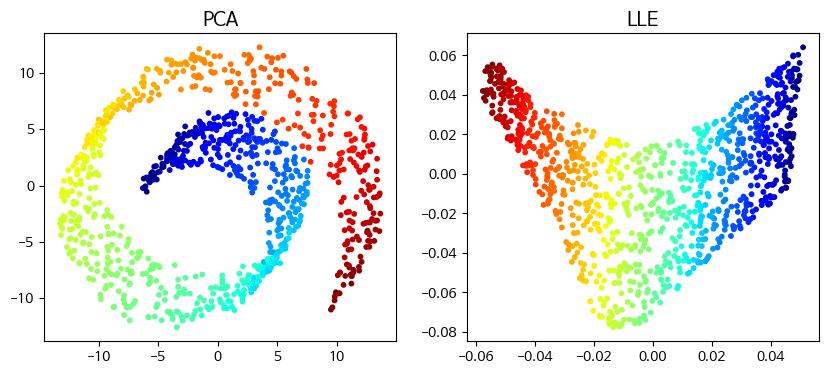

In [37]:
# PCA와의 비교
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

X_pca = PCA(n_components=2).fit_transform(X_swiss)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=t, cmap="jet", s=10)
axes[0].set_title("PCA")
axes[1].scatter(X_unrolled[:, 0], X_unrolled[:, 1], c=t, cmap="jet", s=10)
axes[1].set_title("LLE")
plt.show()

LLE의 한계


*   가까운 관계만 보존: 이웃끼리의 관계는 잘 유지되나, 멀리 떨어진 점들 사이 거리는 부정확
*   데이터가 크면 속도 저하: 2단계 계산량이 샘플 수의 제곱에 비례해서 늘어나므로 수십만 개 이상의 대용량 데이터에는 부적합

# 다른 차원 축소 기법
1. MDS(다차원 스케일링)<BR>
* 점들 사이의 거리를 최대한 유지하면서 차원 축소
* 랜덤투영과는 달리 무작위가 아니라 거리가 가장 잘 맞도록 좌표를 직접 계산함
* 멀리 떨어진 점들 사이 거리까지 맞추려다 보니 휘어진 데이터는 잘 펼치지 못함

2. Isomap
* 각 점을 가까운 이웃과 선으로 연결해서 그래프를 만들고, 그 선을 따라 이동한 거리(지오데식 거리)를 활용
* 선을 따라 이동한 거리를 유지하므로 롤을 제대로 펼칠 수 있음

3. t-SNE
* 비슷한 점들은 가깝게, 다른 점들은 멀리 배치
* 주로 시각화에 활용, 차원 데이터를 2D나 3D로 줄여서 군집이 어떻게 나뉘는지 확인하기에 적합

4. LDA(선형 판별 분석)
* 원래는 분류 알고리즘, 학습하면서 클래스끼리 가장 잘 구분되는 축을 찾아 그 축으로 투영하여 차원 축소
* 라벨 활용 -> 정답을 보고 클래스가 잘 나뉘는 방향 고름
* 분류 모델을 쓰기 전 차원을 줄이는 용도로 활용

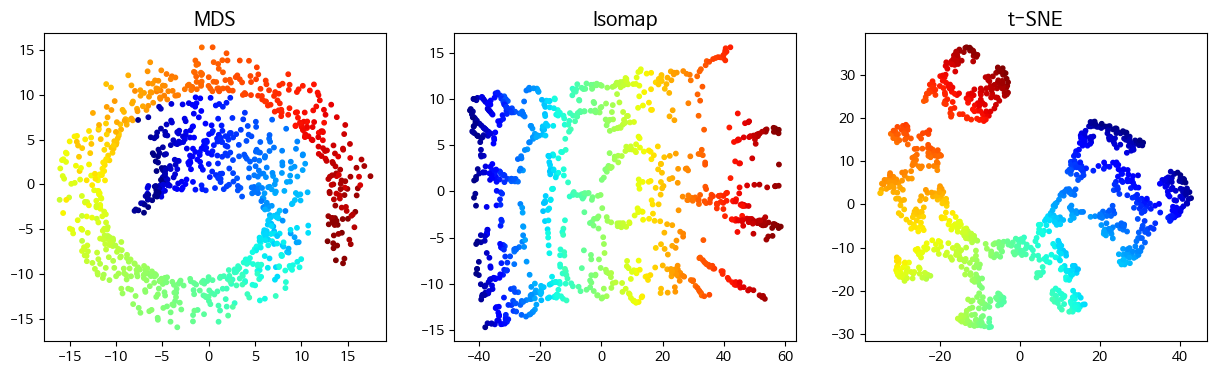

In [38]:
from sklearn.manifold import MDS, Isomap, TSNE
import matplotlib.pyplot as plt

X_mds = MDS(n_components=2, random_state=42).fit_transform(X_swiss)
X_isomap = Isomap(n_components=2).fit_transform(X_swiss)
X_tsne = TSNE(n_components=2, init="random", learning_rate="auto",
              random_state=42).fit_transform(X_swiss)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, X_2d, title in zip(axes, [X_mds, X_isomap, X_tsne], ["MDS", "Isomap", "t-SNE"]):
    ax.scatter(X_2d[:, 0], X_2d[:, 1], c=t, cmap="jet", s=10)
    ax.set_title(title)
plt.show()